In [4]:
import sys
!{sys.executable} -m pip install xgboost

In [1]:
import xgboost
print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1



1. LOADING DATASET
Dataset shape: (7200, 15)

Columns:
['simulation_id', 'timestamp', 'node_id', 'x', 'y', 'speed', 'battery_level', 'cpu_usage', 'memory_usage', 'signal_strength', 'packet_loss', 'latency', 'active', 'faulty', 'fault_type']

Original class distribution:
fault_type
NORMAL                6797
CHANNEL_CONGESTION      62
RADIO_INTERFERENCE      62
LINK_FAILURE            62
HIGH_PACKET_LOSS        62
HIGH_LATENCY            62
HIGH_CPU                31
LOW_BATTERY             31
NODE_FAILURE            31
Name: count, dtype: int64

2. CLEANING DATA
Duplicates removed: 0

Cleaned dataset shape: (7200, 15)

Cleaned class distribution:
fault_type
NORMAL                6797
CHANNEL_CONGESTION      62
RADIO_INTERFERENCE      62
LINK_FAILURE            62
HIGH_PACKET_LOSS        62
HIGH_LATENCY            62
HIGH_CPU                31
LOW_BATTERY             31
NODE_FAILURE            31
Name: count, dtype: int64

3. PREPARING FEATURES

4. SELECTING FEATURES

Processing timest

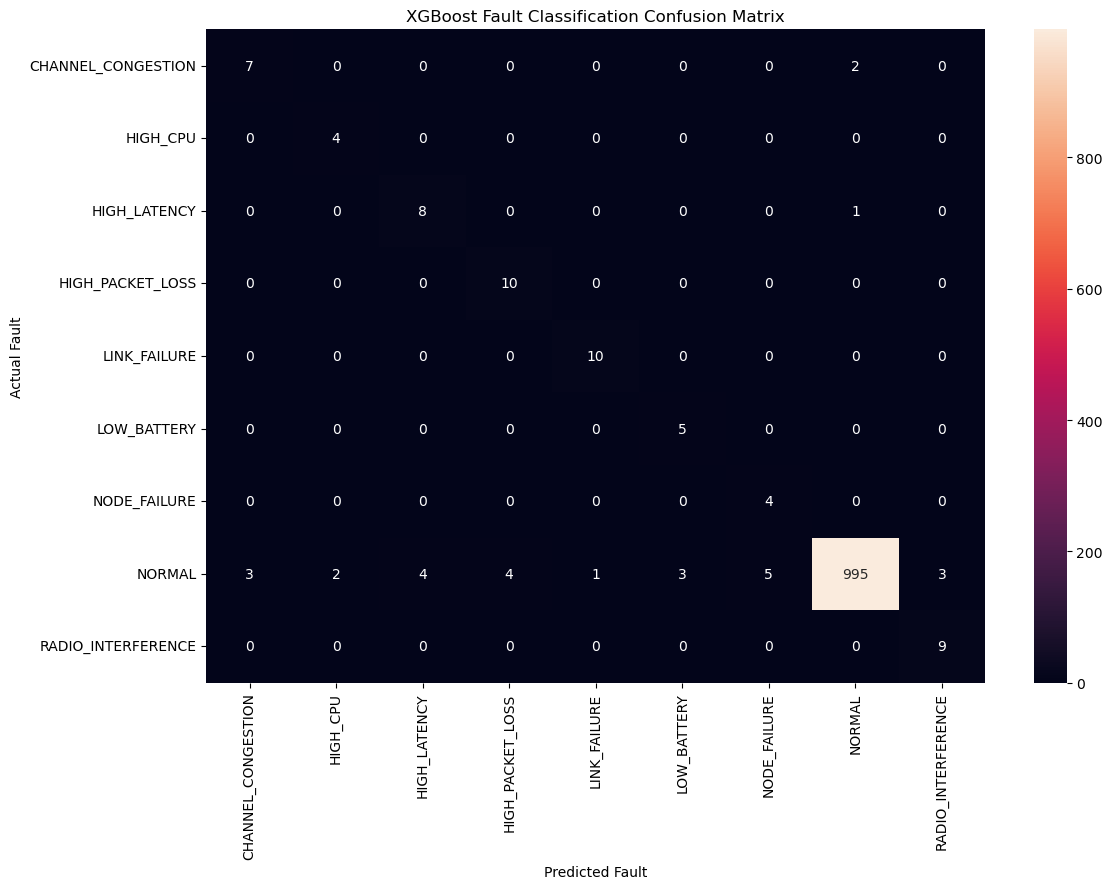

Saved: fault_xgboost_model\confusion_matrix.png

15. FEATURE IMPORTANCE
         feature  importance
          active    0.397164
   battery_level    0.260412
           speed    0.101124
               x    0.052581
         latency    0.049344
     packet_loss    0.043229
               y    0.042682
       cpu_usage    0.025213
 signal_strength    0.019104
    memory_usage    0.009146
  timestamp_year    0.000000
 timestamp_month    0.000000
   timestamp_day    0.000000
  timestamp_hour    0.000000
timestamp_minute    0.000000


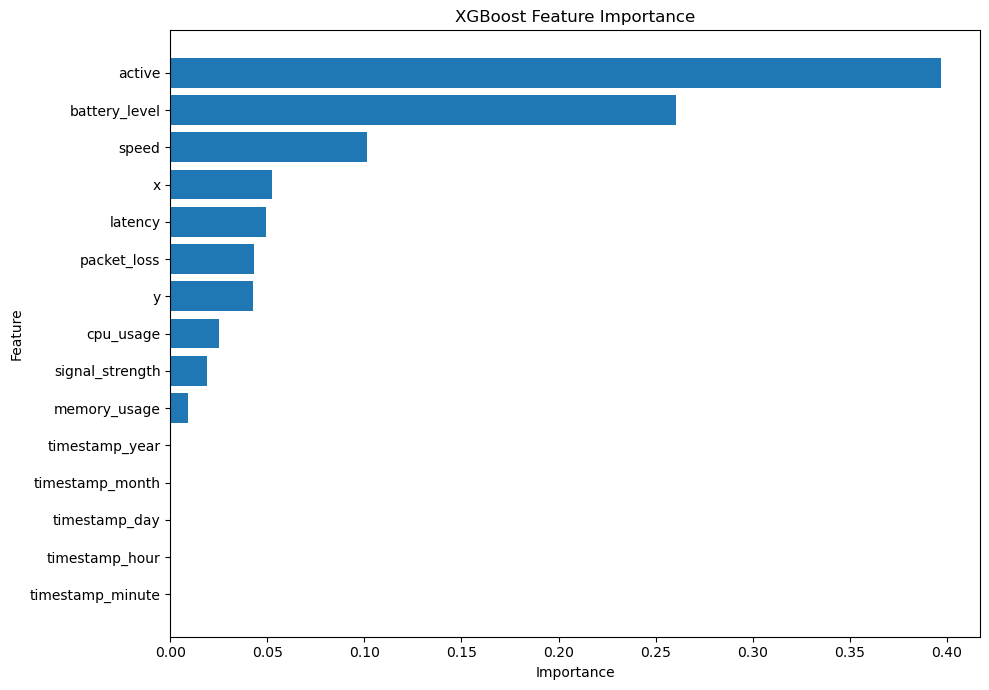


16. SAVING PREDICTIONS
Saved: fault_xgboost_model\test_predictions.csv

17. SAVING TRAINED MODEL

18. SAVING METRICS

TRAINING PIPELINE COMPLETE

Trained model:
fault_xgboost_model\fault_classifier_xgboost.json

Label mapping:
fault_xgboost_model\label_mapping.json

Metrics:
fault_xgboost_model\metrics.json

Classification report:
fault_xgboost_model\classification_report.txt

Confusion matrix:
fault_xgboost_model\confusion_matrix.png

Feature importance:
fault_xgboost_model\feature_importance.csv

Test predictions:
fault_xgboost_model\test_predictions.csv

MODEL READY FOR INFERENCE


In [3]:
# ============================================================
# NETWORK FAULT CLASSIFICATION USING XGBOOST
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_sample_weight


# ============================================================
# CONFIGURATION
# ============================================================

DATASET_PATH = "fault_classification_dataset.csv"

OUTPUT_DIR = "fault_xgboost_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 1. LOAD DATASET
# ============================================================

print("\n========================================")
print("1. LOADING DATASET")
print("========================================")

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nOriginal class distribution:")
print(df["fault_type"].value_counts())


# ============================================================
# 2. CLEAN DATA
# ============================================================

print("\n========================================")
print("2. CLEANING DATA")
print("========================================")

# Clean column names
df.columns = [
    column.strip().lower().replace(" ", "_")
    for column in df.columns
]

# Remove completely empty rows
df = df.dropna(how="all")

# Remove duplicate rows
before_duplicates = len(df)

df = df.drop_duplicates()

duplicates_removed = (
    before_duplicates - len(df)
)

print("Duplicates removed:", duplicates_removed)


# ============================================================
# NORMALIZE TARGET LABELS
# ============================================================

df["fault_type"] = (
    df["fault_type"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# VALID FAULT CLASSES
# ============================================================

valid_labels = [
    "NORMAL",
    "LOW_BATTERY",
    "NODE_FAILURE",
    "HIGH_CPU",
    "HIGH_LATENCY",
    "HIGH_PACKET_LOSS",
    "LINK_FAILURE",
    "RADIO_INTERFERENCE",
    "CHANNEL_CONGESTION"
]

# Remove invalid target rows
df = df[
    df["fault_type"].isin(valid_labels)
].copy()

print("\nCleaned dataset shape:", df.shape)

print("\nCleaned class distribution:")
print(df["fault_type"].value_counts())


# ============================================================
# 3. PREPARE BOOLEAN FEATURES
# ============================================================

print("\n========================================")
print("3. PREPARING FEATURES")
print("========================================")

boolean_columns = [
    "active",
    "faulty"
]

for column in boolean_columns:

    if column in df.columns:

        # Handle True/False and 1/0 values
        if df[column].dtype == "object":

            df[column] = (
                df[column]
                .astype(str)
                .str.strip()
                .str.lower()
                .map({
                    "true": 1,
                    "false": 0,
                    "yes": 1,
                    "no": 0,
                    "1": 1,
                    "0": 0
                })
            )

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


# ============================================================
# 4. SELECT FEATURES
# ============================================================

print("\n========================================")
print("4. SELECTING FEATURES")
print("========================================")

# We do not use:
#
# simulation_id -> identifies simulation
# node_id       -> identifies node
# fault_type    -> target variable
#
# Timestamp is converted into useful time-based features.

BASE_FEATURE_COLUMNS = [
    "x",
    "y",
    "speed",
    "battery_level",
    "cpu_usage",
    "memory_usage",
    "signal_strength",
    "packet_loss",
    "latency",
    "active"
]


# Check required columns
missing_features = [
    column
    for column in BASE_FEATURE_COLUMNS
    if column not in df.columns
]

if missing_features:

    raise ValueError(
        "Missing feature columns: "
        + str(missing_features)
    )


# ============================================================
# 5. CREATE X AND TARGET
# ============================================================

X = df[BASE_FEATURE_COLUMNS].copy()

y_text = df["fault_type"].copy()


# ============================================================
# 6. HANDLE TIMESTAMP
# ============================================================

if "timestamp" in df.columns:

    print("\nProcessing timestamp...")

    timestamp = pd.to_datetime(
        df["timestamp"],
        errors="coerce"
    )

    X["timestamp_year"] = timestamp.dt.year
    X["timestamp_month"] = timestamp.dt.month
    X["timestamp_day"] = timestamp.dt.day
    X["timestamp_hour"] = timestamp.dt.hour
    X["timestamp_minute"] = timestamp.dt.minute

else:

    print("\nTimestamp column not found.")

    # Create default values if timestamp does not exist
    X["timestamp_year"] = 0
    X["timestamp_month"] = 0
    X["timestamp_day"] = 0
    X["timestamp_hour"] = 0
    X["timestamp_minute"] = 0


# ============================================================
# FINAL FEATURE LIST
# ============================================================

FEATURE_COLUMNS = [
    "x",
    "y",
    "speed",
    "battery_level",
    "cpu_usage",
    "memory_usage",
    "signal_strength",
    "packet_loss",
    "latency",
    "active",
    "timestamp_year",
    "timestamp_month",
    "timestamp_day",
    "timestamp_hour",
    "timestamp_minute"
]


# ============================================================
# 7. HANDLE NUMERIC VALUES
# ============================================================

print("\n========================================")
print("5. HANDLING NUMERIC VALUES")
print("========================================")

for column in FEATURE_COLUMNS:

    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )


# Replace infinity values
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# Fill missing values using median
for column in FEATURE_COLUMNS:

    median_value = X[column].median()

    # If entire column is empty, use 0
    if pd.isna(median_value):
        median_value = 0

    X[column] = X[column].fillna(
        median_value
    )


print("\nFeatures used by XGBoost:")

for feature in FEATURE_COLUMNS:

    print(" -", feature)


# ============================================================
# 8. ENCODE FAULT CLASSES
# ============================================================

print("\n========================================")
print("6. ENCODING FAULT CLASSES")
print("========================================")

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    y_text
)

classes = label_encoder.classes_


print("\nClass mapping:")

for class_id, label in enumerate(classes):

    print(
        class_id,
        "->",
        label
    )


# ============================================================
# SAVE LABEL MAPPING
# ============================================================

label_mapping = {
    str(index): label
    for index, label in enumerate(classes)
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "label_mapping.json"
    ),
    "w"
) as file:

    json.dump(
        label_mapping,
        file,
        indent=4
    )


# ============================================================
# 9. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("\n========================================")
print("7. SPLITTING DATASET")
print("========================================")

# 70% Training
# 15% Validation
# 15% Testing

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("\nTraining records:", len(X_train))
print("Validation records:", len(X_validation))
print("Testing records:", len(X_test))


# ============================================================
# 10. HANDLE CLASS IMBALANCE
# ============================================================

print("\n========================================")
print("8. HANDLING CLASS IMBALANCE")
print("========================================")

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print(
    "Balanced sample weights generated."
)


# ============================================================
# 11. CREATE XGBOOST MODEL
# ============================================================

print("\n========================================")
print("9. CREATING XGBOOST MODEL")
print("========================================")

model = XGBClassifier(

    objective="multi:softprob",

    num_class=len(classes),

    n_estimators=500,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.85,

    colsample_bytree=0.85,

    min_child_weight=2,

    gamma=0,

    reg_alpha=0.1,

    reg_lambda=1.0,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)


# ============================================================
# 12. TRAIN MODEL
# ============================================================

print("\n========================================")
print("10. TRAINING XGBOOST")
print("========================================")

model.fit(

    X_train,

    y_train,

    sample_weight=sample_weights,

    eval_set=[
        (
            X_train,
            y_train
        ),
        (
            X_validation,
            y_validation
        )
    ],

    verbose=True
)


print("\nTraining completed successfully.")


# ============================================================
# 13. VALIDATION
# ============================================================

print("\n========================================")
print("11. VALIDATION")
print("========================================")

validation_predictions = model.predict(
    X_validation
)


validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

validation_precision = precision_score(
    y_validation,
    validation_predictions,
    average="weighted",
    zero_division=0
)

validation_recall = recall_score(
    y_validation,
    validation_predictions,
    average="weighted",
    zero_division=0
)

validation_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="weighted",
    zero_division=0
)


print("\nValidation Accuracy:",
      round(validation_accuracy, 4))

print("Validation Precision:",
      round(validation_precision, 4))

print("Validation Recall:",
      round(validation_recall, 4))

print("Validation F1:",
      round(validation_f1, 4))


# ============================================================
# 14. FINAL TEST
# ============================================================

print("\n========================================")
print("12. FINAL TEST")
print("========================================")

test_predictions = model.predict(
    X_test
)

test_probabilities = model.predict_proba(
    X_test
)


test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)


print("\nFINAL TEST RESULTS")

print(
    "Accuracy :",
    round(test_accuracy, 4)
)

print(
    "Precision:",
    round(test_precision, 4)
)

print(
    "Recall   :",
    round(test_recall, 4)
)

print(
    "F1 Score :",
    round(test_f1, 4)
)


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\n========================================")
print("13. CLASSIFICATION REPORT")
print("========================================")

report = classification_report(

    y_test,

    test_predictions,

    target_names=classes,

    zero_division=0
)

print(report)


with open(
    os.path.join(
        OUTPUT_DIR,
        "classification_report.txt"
    ),
    "w"
) as file:

    file.write(report)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

print("\n========================================")
print("14. CONFUSION MATRIX")
print("========================================")

cm = confusion_matrix(
    y_test,
    test_predictions
)


plt.figure(
    figsize=(12, 9)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Fault")

plt.ylabel("Actual Fault")

plt.title(
    "XGBoost Fault Classification Confusion Matrix"
)

plt.tight_layout()


confusion_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix.png"
)


plt.savefig(
    confusion_path,
    dpi=300
)

plt.show()

plt.close()


print(
    "Saved:",
    confusion_path
)


# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

print("\n========================================")
print("15. FEATURE IMPORTANCE")
print("========================================")

importance = pd.DataFrame({

    "feature":
        FEATURE_COLUMNS,

    "importance":
        model.feature_importances_

})


importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)


print(
    importance.to_string(
        index=False
    )
)


# ============================================================
# SAVE FEATURE IMPORTANCE
# ============================================================

importance_path = os.path.join(
    OUTPUT_DIR,
    "feature_importance.csv"
)

importance.to_csv(
    importance_path,
    index=False
)


# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()


feature_plot_path = os.path.join(
    OUTPUT_DIR,
    "feature_importance.png"
)


plt.savefig(
    feature_plot_path,
    dpi=300
)

plt.show()

plt.close()


# ============================================================
# 18. SAVE TEST PREDICTIONS
# ============================================================

print("\n========================================")
print("16. SAVING PREDICTIONS")
print("========================================")

test_results = X_test.copy()


test_results["actual_class_id"] = (
    y_test
)


test_results["predicted_class_id"] = (
    test_predictions
)


test_results["actual_fault_type"] = (
    label_encoder.inverse_transform(
        y_test
    )
)


test_results["predicted_fault_type"] = (
    label_encoder.inverse_transform(
        test_predictions
    )
)


test_results["prediction_confidence"] = (
    np.max(
        test_probabilities,
        axis=1
    )
)


predictions_path = os.path.join(
    OUTPUT_DIR,
    "test_predictions.csv"
)


test_results.to_csv(
    predictions_path,
    index=False
)


print(
    "Saved:",
    predictions_path
)


# ============================================================
# 19. SAVE TRAINED MODEL
# ============================================================

print("\n========================================")
print("17. SAVING TRAINED MODEL")
print("========================================")


model_path = os.path.join(
    OUTPUT_DIR,
    "fault_classifier_xgboost.json"
)


model.save_model(
    model_path
)


# ============================================================
# SAVE FEATURE CONFIGURATION
# ============================================================

with open(
    os.path.join(
        OUTPUT_DIR,
        "feature_columns.json"
    ),
    "w"
) as file:

    json.dump(
        FEATURE_COLUMNS,
        file,
        indent=4
    )


# ============================================================
# SAVE LABEL ENCODER
# ============================================================

joblib.dump(
    label_encoder,
    os.path.join(
        OUTPUT_DIR,
        "label_encoder.pkl"
    )
)


# ============================================================
# 20. SAVE METRICS
# ============================================================

print("\n========================================")
print("18. SAVING METRICS")
print("========================================")


metrics = {

    "validation_accuracy":
        float(validation_accuracy),

    "validation_precision":
        float(validation_precision),

    "validation_recall":
        float(validation_recall),

    "validation_f1":
        float(validation_f1),

    "test_accuracy":
        float(test_accuracy),

    "test_precision":
        float(test_precision),

    "test_recall":
        float(test_recall),

    "test_f1":
        float(test_f1),

    "number_of_classes":
        len(classes),

    "training_records":
        len(X_train),

    "validation_records":
        len(X_validation),

    "test_records":
        len(X_test),

    "features":
        FEATURE_COLUMNS
}


metrics_path = os.path.join(
    OUTPUT_DIR,
    "metrics.json"
)


with open(
    metrics_path,
    "w"
) as file:

    json.dump(
        metrics,
        file,
        indent=4
    )


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n========================================")
print("TRAINING PIPELINE COMPLETE")
print("========================================")


print("\nTrained model:")
print(model_path)


print("\nLabel mapping:")
print(
    os.path.join(
        OUTPUT_DIR,
        "label_mapping.json"
    )
)


print("\nMetrics:")
print(metrics_path)


print("\nClassification report:")
print(
    os.path.join(
        OUTPUT_DIR,
        "classification_report.txt"
    )
)


print("\nConfusion matrix:")
print(confusion_path)


print("\nFeature importance:")
print(importance_path)


print("\nTest predictions:")
print(predictions_path)


print("\n========================================")
print("MODEL READY FOR INFERENCE")
print("========================================")